Measure how often recalls move from a newly revisited repeated item to the neighbours of its earlier presentation. The `min_lag` filter enforces spaced repetitions, and the resulting curve highlights backward spread relative to the full forward/backward profile charted in `repcrp`.

Adjust `control_trial_query` to define alternative control populations.

Modify `min_lag` if you need to tighten or relax the spacing filter.


In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.cleanbackrepcrp import (
    plot_back_rep_crp,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


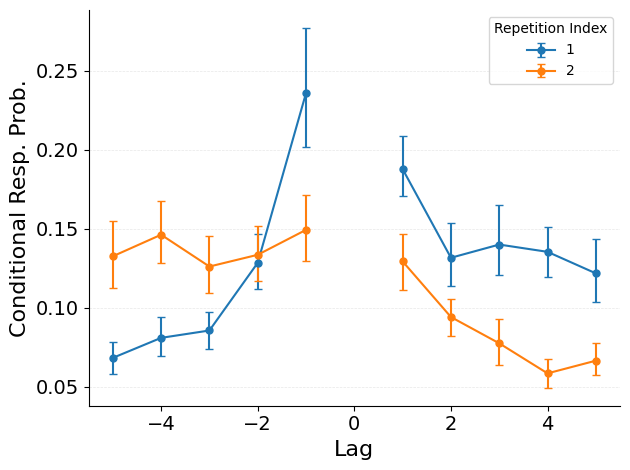

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:141: RuntimeWarning: invalid value encountered in subtract
  U_ji = [(n - 1) * (theta_hat_dot - theta_hat_i)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


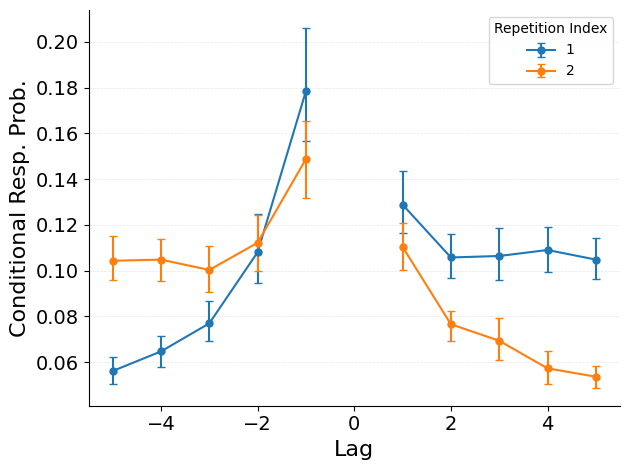

In [4]:
plot_back_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")
plot_back_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [5]:
observed_crp = subject_back_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_back_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_back_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    1.836     0.0751 |    212.0     0.0934 |     0.0122
   -4 |    2.632     0.0127 |    170.0     0.0166 |     0.0163
   -3 |    1.331     0.1921 |    238.0     0.2131 |     0.0087
   -2 |    2.314     0.0268 |    194.0     0.0475 |     0.0204
   -1 |    4.946     0.0000 |     62.0     0.0000 |     0.0574
    0 |      nan        nan |      nan        nan |        nan
    1 |    5.331     0.0000 |     59.0     0.0000 |     0.0590
    2 |    2.767     0.0091 |    195.0     0.0495 |     0.0259
    3 |    3.786     0.0006 |    119.0     0.0009 |     0.0337
    4 |    3.395     0.0018 |    128.0     0.0016 |     0.0264
    5 |    1.680     0.1021 |    249.0     0.2872 |     0.0170

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:476: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:487: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [6]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |   -1.529     0.1356 |    203.0     0.0674 |    -0.0161
   -4 |   -2.171     0.0370 |    196.0     0.0515 |    -0.0252
   -3 |   -1.595     0.1200 |    234.0     0.1898 |    -0.0172
   -2 |   -0.079     0.9374 |    293.0     0.7280 |    -0.0010
   -1 |    3.538     0.0012 |    106.0     0.0004 |     0.0569
    0 |      nan        nan |      nan        nan |        nan
    1 |    3.413     0.0017 |    144.0     0.0043 |     0.0400
    2 |    0.681     0.5004 |    291.0     0.7038 |     0.0083
    3 |    2.570     0.0147 |    183.0     0.0300 |     0.0255
    4 |    2.625     0.0129 |    162.0     0.0112 |     0.0252
    5 |    0.339     0.73

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:531: RuntimeWarning: invalid value encountered in subtract
  control_diff = control_crp[:, 0, :] - control_crp[:, 1, :]
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:545: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:556: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
